# CO543: Image Processing - Lab 8 (2025)
### E/21/245
### Madhushan S.K.A.K.

## Task 1 — Visualize the Frequency Spectrum

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image = cv2.imread('car.jpg')

In [3]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [4]:
# Frequency-Domain Transformation (Fourier Transform)
F = np.fft.fftshift(np.fft.fft2(gray))

In [5]:
# calculate the magnitude spectrum
mag = np.log1p(np.abs(F))

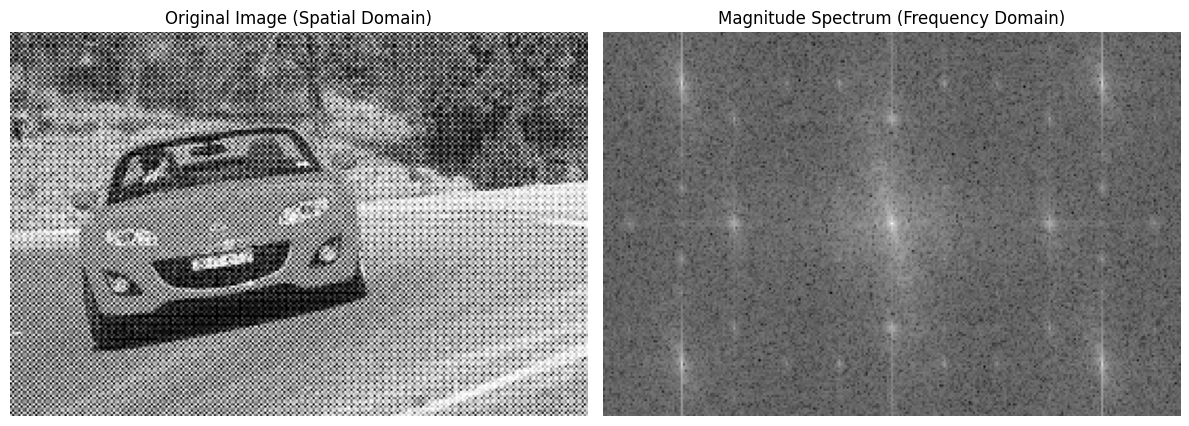

In [8]:
# Display the resu;ts side by side
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Original Image (Spatial Domain)')
plt.axis('off')
# FFT Spectrum
plt.subplot(1, 2, 2)
plt.imshow(mag, cmap='gray')
plt.title('Magnitude Spectrum (Frequency Domain)')
plt.axis('off')
plt.tight_layout()
plt.show()

### Results :-
The 2D Fast Fourier Transform (FFT) of the grayscale halftone car image was successfully computed. The zero-frequency component was shifted to the center, and the magnitude spectrum was visualized using a logarithmic scale to reveal both high and low-frequency components clearly.

### Observations:-
- Low-Frequency Content (Central Region):- The bright, concentrated region exactly in the center of the spectrum represents the low-frequency components. This corresponds to the overall structure, smooth gradients, and general illumination of the car and the background.

- Repetitive Artifacts (Scattered Components):-
Surrounding the central region, there is a distinct, symmetric grid of bright spikes (star-like dots). These scattered components indicate high-frequency, repetitive fine details. In this specific image, these spikes are the direct frequency-domain representation of the periodic halftone dot pattern covering the car.

### More to think:-If a repeating dot or stripe pattern appears in the image, what kind of structure do you expect to see in the spectrum?

If a repeating dot or stripe pattern is present in the spatial image, it acts as a periodic, structured signal. Therefore, we expect to see isolated, bright spikes (or sharp dots) located symmetrically away from the center of the magnitude spectrum.

- A repeating stripe pattern will create spikes along a single line (perpendicular to the stripes).

- A repeating dot pattern (like a grid) will create a corresponding grid of bright spikes in the spectrum. The distance of these spikes from the center indicates how tightly packed the dots or stripes are in the original image.

## Task 2 — Design Mask, Filter, and Reconstruct

In [9]:
# Compute the 2D FFT and shift the zero-frequency component to the center
F = np.fft.fftshift(np.fft.fft2(gray))

In [10]:
# Function to create a Low-Pass Mask
def create_lowpass_mask(shape, radius):
    rows, cols = shape
    center_row, center_col = rows // 2, cols // 2

    # Calculate the distance from the center to every pixel in the image
    y, x = np.ogrid[:rows, :cols]
    distance = np.sqrt((x - center_col)**2 + (y - center_row)**2)

    # Set to 1 (White) if the distance is less than or equal to the radius, else 0 (Black)
    mask = distance <= radius
    return mask.astype(float)

In [36]:
# Create the mask and multiply it with the shifted FFT
R = 55 # experimental value use here
mask = create_lowpass_mask(F.shape, radius=R)

In [37]:
# Apply the filter by multiplying the frequency spectrum with the mask
F_filt = F * mask

In [38]:
# Reconstruct the image using Inverse FFT
# First, shift the zero-frequency component back to the corners (ifftshift)
clean = np.fft.ifft2(np.fft.ifftshift(F_filt))

In [39]:
# Since the inverse FFT returns complex numbers, we take the absolute value (magnitude)
clean = np.abs(clean)

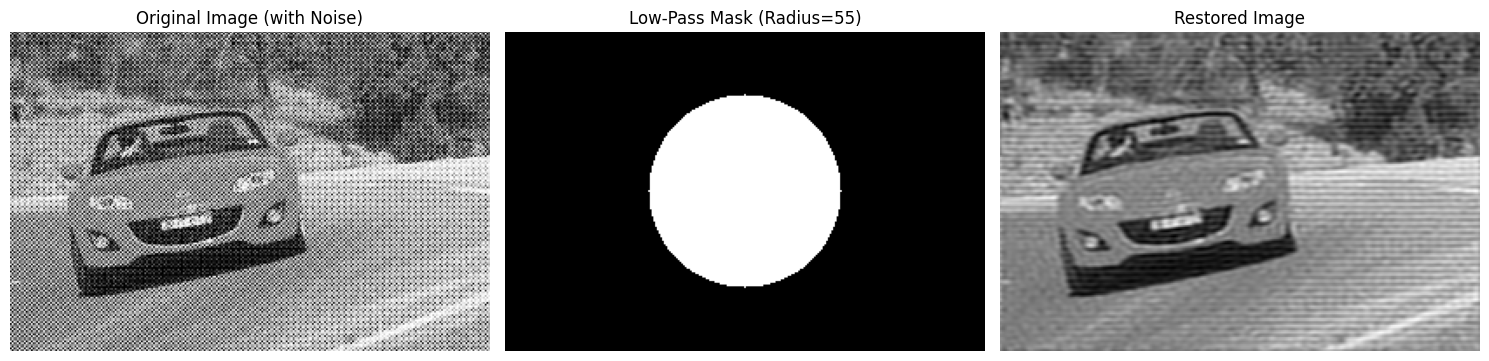

In [40]:
# Display the results side-by-side
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title('Original Image (with Noise)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title(f'Low-Pass Mask (Radius={R})')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(clean, cmap='gray')
plt.title('Restored Image')
plt.axis('off')

plt.tight_layout()
plt.show()

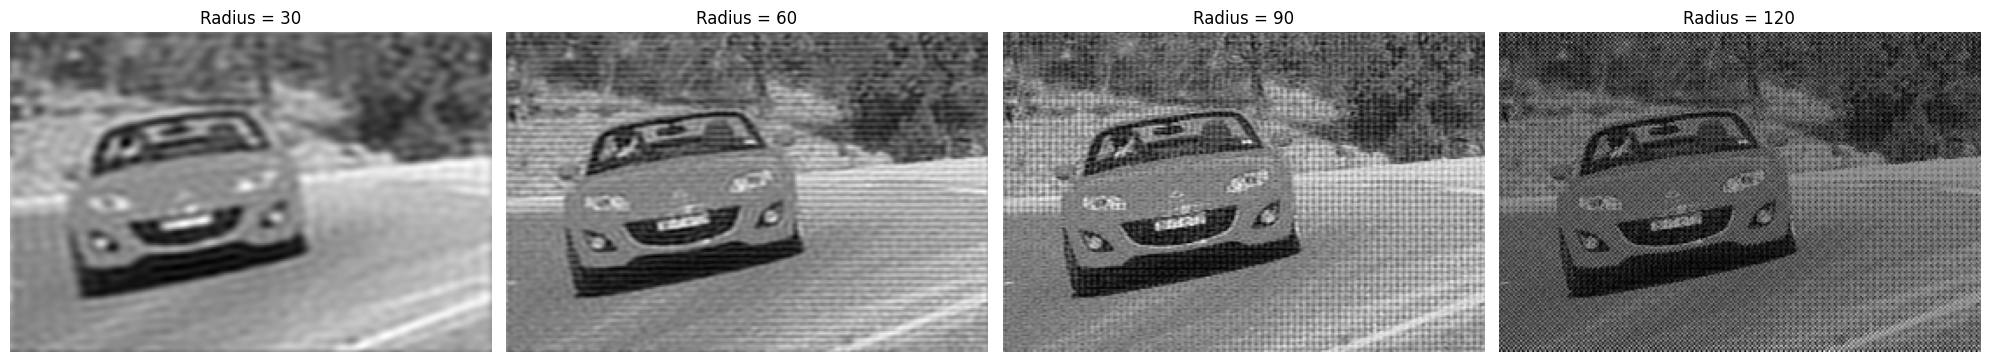

In [44]:
# Loop through multiple radii (just to see)
radii = [30, 60, 90, 120]  # List of radius values to test
plt.figure(figsize=(20, 5))

for i, R in enumerate(radii):
    # Create mask for current radius
    mask = create_lowpass_mask(F.shape, radius=R)

    # Apply filter
    F_filt = F * mask

    # Reconstruct image (Inverse FFT)
    clean = np.abs(np.fft.ifft2(np.fft.ifftshift(F_filt)))

    # Plot results side-by-side
    plt.subplot(1, len(radii), i + 1)
    plt.imshow(clean, cmap='gray')
    plt.title(f'Radius = {R}')
    plt.axis('off')

plt.tight_layout()
plt.show()

### Observations on Filter Design and Reconstruction-

Based on the generated output, a circular Low-Pass Mask with a radius of 55 was applied to the frequency spectrum.

- Effect on Pattern Noise:- Multiplying the spectrum by this mask successfully blocked the high-frequency spikes located outside the central circle. As seen in the "Restored Image," this effectively removed the harsh, repeating halftone dot pattern covering the car.

- Details Preserved/Lost:- The general shape, shading, and structure of the car (low-frequency content) were well preserved. However, because the circular mask completely cut off all high frequencies beyond a certain point, the restored image lost its sharp edges and fine details, resulting in a slightly blurred appearance. Additionally, faint horizontal banding or "ringing" artifacts are visible in the restored image, which is a common side effect of using a hard-edged circular mask (the Gibbs phenomenon).

### More to think:-
### 1. Why does removing too much high-frequency content make the image blurry?

- Why does removing too much high-frequency content make the image blurry?
In an image, high frequencies represent areas where pixel intensity changes rapidly. These rapid changes form the crisp lines, sharp edges, and fine details we see. If we remove too much high-frequency content (for example, by making the mask radius too small), we strip away these sharp boundaries. The image is left with only low-frequency content (slow, gradual color changes), which the human eye perceives as a soft, out-of-focus, or blurry image.

### 2. When could frequency filtering damage important natural textures instead of just noise?
- Natural textures such as the roughness of an asphalt road, grass, human hair, or fabric are inherently made up of high-frequency details. Frequency filtering damages these natural textures when the frequency of the texture overlaps with the frequency of the noise we are trying to remove. If we use a broad low-pass filter, it cannot tell the difference between "bad" high-frequency noise and "good" high-frequency texture; it simply removes both, leaving the natural surfaces looking artificially smooth or "plastic."

## Final Reflection

Frequency-domain analysis is a great partner to spatial filtering because they both solve different kinds of problems. Spatial filtering (like using a regular blur) works directly on the pixels and is best for fixing small, random spots or "salt-and-pepper" noise.  However, spatial filters are not good at removing repeating patterns that cover the whole image if you try to blur out a heavy dot pattern using spatial tools, you will just make the entire image a blurry mess.

This is where the frequency domain is much better. By turning the image into frequencies, a repeating pattern becomes a few bright dots that we can easily find and delete. In short, you should use spatial filtering for small, random mistakes in an image, and use frequency filtering for structured patterns like dots, stripes, or electronic interference.

In [ ]:
|